# 📊 RecycleVision — Model Evaluation (All 5 Models)
**Project:** Garbage Image Classification Using Deep Learning  
**Notebook:** 04_Model_Evaluation.ipynb  
**Goal:** Evaluate all 5 trained models on Test Set and select the Best Model  
**Metrics:** Accuracy | Precision | Recall | F1-Score | Confusion Matrix | ROC Curve

## 🔲 Cell 1 — Import Libraries

In [1]:
# Cell 1 - Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet50     import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16        import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

print('✅ All libraries imported successfully!')
print(f'   TensorFlow : {tf.__version__}')

✅ All libraries imported successfully!
   TensorFlow : 2.21.0


## 🔲 Cell 2 — Set Paths & Load Class Names

In [ ]:
# Cell 2 - Set Paths
TEST_PATH   = r"D:\RecycleVision\data\processed\test"
MODELS_PATH = r"D:\RecycleVision\models"

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
CLASSES     = sorted(os.listdir(TEST_PATH))
NUM_CLASSES = len(CLASSES)

# Model registry — name, file, preprocess function
MODEL_REGISTRY = [
    {'name': 'MobileNetV2',    'file': 'mobilenetv2_model.h5',    'preprocess': mobilenet_preprocess,    'color': '#22d3ee', 'icon': '⚡'},
    {'name': 'EfficientNetB0', 'file': 'efficientnetb0_model.h5', 'preprocess': efficientnet_preprocess, 'color': '#818cf8', 'icon': '🎯'},
    {'name': 'ResNet50',       'file': 'resnet50_model.h5',       'preprocess': resnet_preprocess,       'color': '#34d399', 'icon': '🏗️'},
    {'name': 'VGG16',          'file': 'vgg16_model.h5',          'preprocess': vgg16_preprocess,        'color': '#fb923c', 'icon': '🔲'},
    {'name': 'InceptionV3',    'file': 'inceptionv3_model.h5',    'preprocess': inception_preprocess,    'color': '#f472b6', 'icon': '🌀'},
]

print('=' * 50)
print('   📂 EVALUATION CONFIGURATION')
print('=' * 50)
print(f'   Test path   : {TEST_PATH}')
print(f'   Classes     : {CLASSES}')
print(f'   Num classes : {NUM_CLASSES}')
print(f'   Models to evaluate : {len(MODEL_REGISTRY)}')
print('=' * 50)

   📂 EVALUATION CONFIGURATION
   Test path   : D:\RecycleVision\data\processed\test
   Classes     : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
   Num classes : 6
   Models to evaluate : 5


## 🔲 Cell 3 — Helper Functions

In [ ]:
# Cell 3 - Helper Functions

def get_test_generator(preprocess_fn):
    """Create test data generator for a specific model"""
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)
    test_gen = test_datagen.flow_from_directory(
        TEST_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    return test_gen


def evaluate_model(model, test_gen):
    """Get predictions and true labels"""
    test_gen.reset()
    y_pred_probs = model.predict(test_gen, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)
    y_true       = test_gen.classes
    return y_true, y_pred, y_pred_probs


def plot_confusion_matrix(y_true, y_pred, model_name, color):
    """Plot confusion matrix heatmap"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d',
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        cmap='Blues',
        linewidths=0.5
    )
    plt.title(f'🔢 {model_name} — Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label',      fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    save_path = os.path.join(MODELS_PATH, f'{model_name}_confusion_matrix.png')
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'   ✅ Confusion matrix saved: {save_path}')


def get_metrics(y_true, y_pred):
    """Calculate all evaluation metrics"""
    return {
        'Accuracy'  : round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision' : round(precision_score(y_true, y_pred, average='weighted') * 100, 2),
        'Recall'    : round(recall_score(y_true, y_pred, average='weighted') * 100, 2),
        'F1-Score'  : round(f1_score(y_true, y_pred, average='weighted') * 100, 2),
    }


# Store results for all models
all_results   = {}
all_metrics   = []
all_y_true    = {}
all_y_pred    = {}
all_y_probs   = {}

print('✅ Helper functions defined!')

✅ Helper functions defined!


## 🔲 Cell 4 — Evaluate Model 1: MobileNetV2 ⚡

⚡ EVALUATING: MobileNetV2


Found 383 images belonging to 6 classes.
   Accuracy  : 84.33%
   Precision : 84.38%
   Recall    : 84.33%
   F1-Score  : 84.25%

📋 Classification Report:
              precision    recall  f1-score   support

   cardboard       0.90      0.92      0.91        61
       glass       0.82      0.76      0.79        76
       metal       0.79      0.90      0.84        62
       paper       0.89      0.90      0.90        90
     plastic       0.85      0.79      0.82        73
       trash       0.70      0.67      0.68        21

    accuracy                           0.84       383
   macro avg       0.83      0.82      0.82       383
weighted avg       0.84      0.84      0.84       383



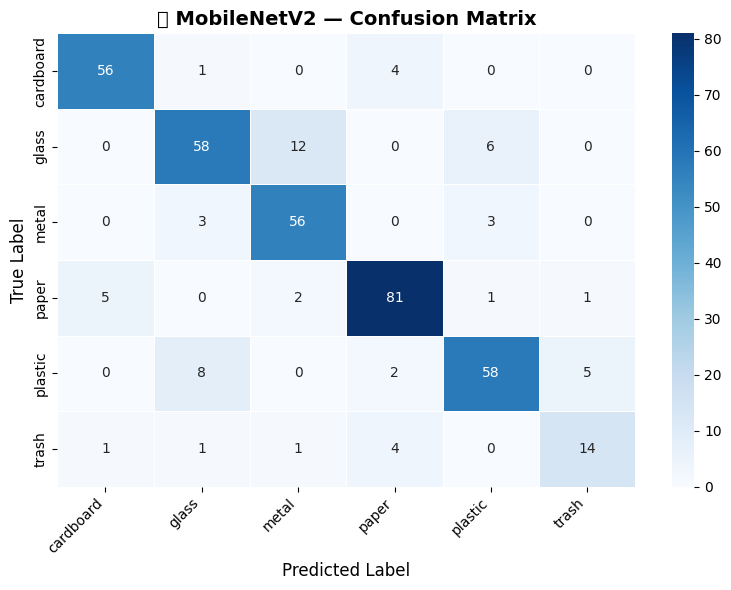

   ✅ Confusion matrix saved: D:\RecycleVision\models\MobileNetV2_confusion_matrix.png


In [ ]:
# Cell 4 - Evaluate MobileNetV2
m = MODEL_REGISTRY[0]
print('=' * 55)
print(f"{m['icon']} EVALUATING: {m['name']}")
print('=' * 55)

# Load model
model     = keras.models.load_model(os.path.join(MODELS_PATH, m['file']))
test_gen  = get_test_generator(m['preprocess'])

# Get predictions
y_true, y_pred, y_probs = evaluate_model(model, test_gen)
all_y_true[m['name']]   = y_true
all_y_pred[m['name']]   = y_pred
all_y_probs[m['name']]  = y_probs

# Metrics
metrics = get_metrics(y_true, y_pred)
metrics['Model'] = m['name']
all_metrics.append(metrics)

print(f"   Accuracy  : {metrics['Accuracy']}%")
print(f"   Precision : {metrics['Precision']}%")
print(f"   Recall    : {metrics['Recall']}%")
print(f"   F1-Score  : {metrics['F1-Score']}%")
print()
print('📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASSES))

# Confusion Matrix
plot_confusion_matrix(y_true, y_pred, m['name'], m['color'])

## 🔲 Cell 5 — Evaluate Model 2: EfficientNetB0 🎯

🎯 EVALUATING: EfficientNetB0


Found 383 images belonging to 6 classes.
   Accuracy  : 78.33%
   Precision : 79.55%
   Recall    : 78.33%
   F1-Score  : 78.18%

📋 Classification Report:
              precision    recall  f1-score   support

   cardboard       0.95      0.89      0.92        61
       glass       0.77      0.70      0.73        76
       metal       0.79      0.53      0.63        62
       paper       0.88      0.91      0.90        90
     plastic       0.67      0.84      0.74        73
       trash       0.55      0.81      0.65        21

    accuracy                           0.78       383
   macro avg       0.77      0.78      0.76       383
weighted avg       0.80      0.78      0.78       383



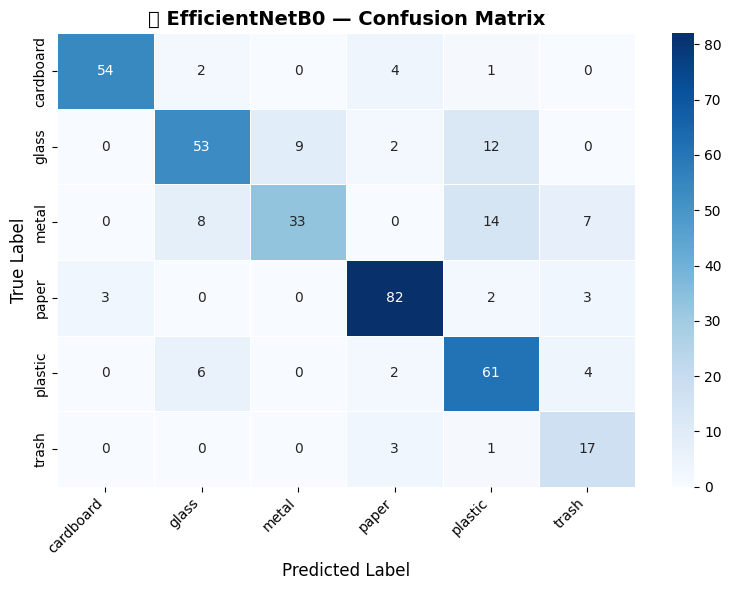

   ✅ Confusion matrix saved: D:\RecycleVision\models\EfficientNetB0_confusion_matrix.png


In [ ]:
# Cell 5 - Evaluate EfficientNetB0
m = MODEL_REGISTRY[1]
print('=' * 55)
print(f"{m['icon']} EVALUATING: {m['name']}")
print('=' * 55)

model     = keras.models.load_model(os.path.join(MODELS_PATH, m['file']))
test_gen  = get_test_generator(m['preprocess'])

y_true, y_pred, y_probs = evaluate_model(model, test_gen)
all_y_true[m['name']]   = y_true
all_y_pred[m['name']]   = y_pred
all_y_probs[m['name']]  = y_probs

metrics = get_metrics(y_true, y_pred)
metrics['Model'] = m['name']
all_metrics.append(metrics)

print(f"   Accuracy  : {metrics['Accuracy']}%")
print(f"   Precision : {metrics['Precision']}%")
print(f"   Recall    : {metrics['Recall']}%")
print(f"   F1-Score  : {metrics['F1-Score']}%")
print()
print('📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASSES))

plot_confusion_matrix(y_true, y_pred, m['name'], m['color'])

## 🔲 Cell 6 — Evaluate Model 3: ResNet50 🏗️

🏗️ EVALUATING: ResNet50


Found 383 images belonging to 6 classes.
   Accuracy  : 90.86%
   Precision : 91.05%
   Recall    : 90.86%
   F1-Score  : 90.81%

📋 Classification Report:
              precision    recall  f1-score   support

   cardboard       0.98      0.93      0.96        61
       glass       0.93      0.82      0.87        76
       metal       0.87      0.97      0.92        62
       paper       0.90      0.96      0.92        90
     plastic       0.89      0.89      0.89        73
       trash       0.90      0.86      0.88        21

    accuracy                           0.91       383
   macro avg       0.91      0.90      0.91       383
weighted avg       0.91      0.91      0.91       383



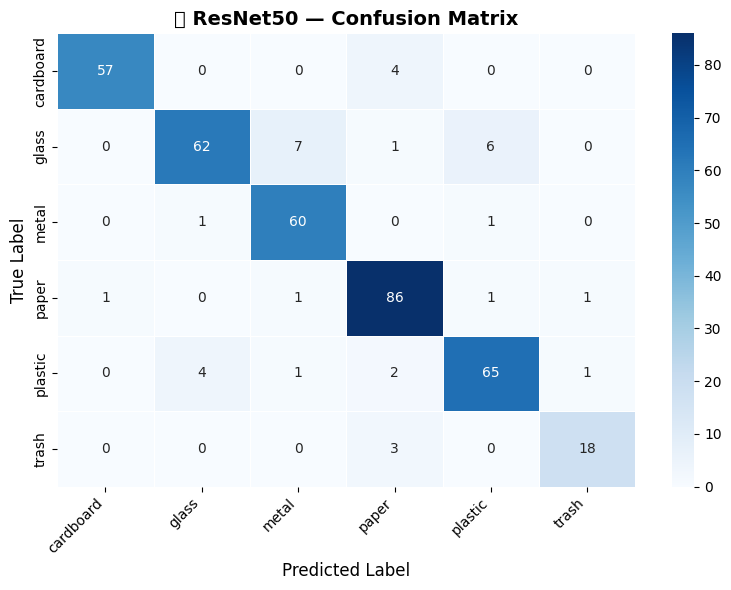

   ✅ Confusion matrix saved: D:\RecycleVision\models\ResNet50_confusion_matrix.png


In [ ]:
# Cell 6 - Evaluate ResNet50
m = MODEL_REGISTRY[2]
print('=' * 55)
print(f"{m['icon']} EVALUATING: {m['name']}")
print('=' * 55)

model     = keras.models.load_model(os.path.join(MODELS_PATH, m['file']))
test_gen  = get_test_generator(m['preprocess'])

y_true, y_pred, y_probs = evaluate_model(model, test_gen)
all_y_true[m['name']]   = y_true
all_y_pred[m['name']]   = y_pred
all_y_probs[m['name']]  = y_probs

metrics = get_metrics(y_true, y_pred)
metrics['Model'] = m['name']
all_metrics.append(metrics)

print(f"   Accuracy  : {metrics['Accuracy']}%")
print(f"   Precision : {metrics['Precision']}%")
print(f"   Recall    : {metrics['Recall']}%")
print(f"   F1-Score  : {metrics['F1-Score']}%")
print()
print('📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASSES))

plot_confusion_matrix(y_true, y_pred, m['name'], m['color'])

## 🔲 Cell 7 — Evaluate Model 4: VGG16 🔲

🔲 EVALUATING: VGG16


Found 383 images belonging to 6 classes.
   Accuracy  : 83.29%
   Precision : 83.78%
   Recall    : 83.29%
   F1-Score  : 83.35%

📋 Classification Report:
              precision    recall  f1-score   support

   cardboard       0.93      0.89      0.91        61
       glass       0.80      0.75      0.78        76
       metal       0.79      0.89      0.83        62
       paper       0.85      0.90      0.88        90
     plastic       0.89      0.78      0.83        73
       trash       0.60      0.71      0.65        21

    accuracy                           0.83       383
   macro avg       0.81      0.82      0.81       383
weighted avg       0.84      0.83      0.83       383



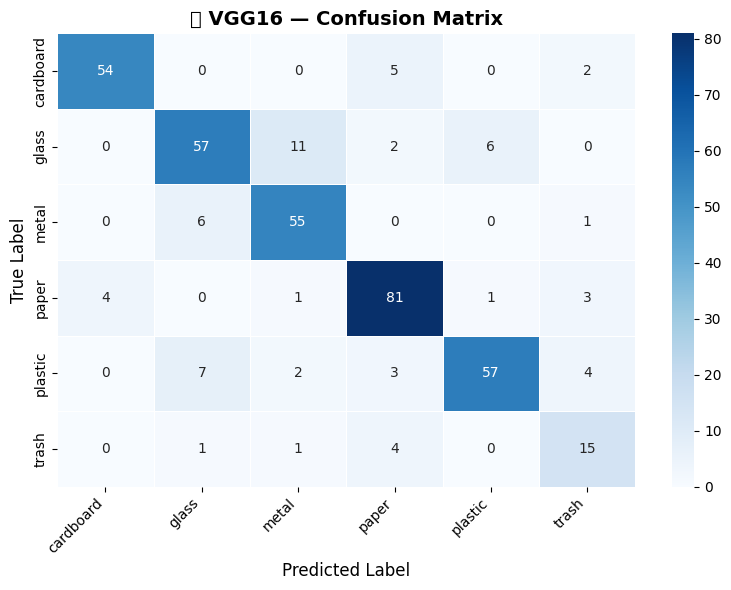

   ✅ Confusion matrix saved: D:\RecycleVision\models\VGG16_confusion_matrix.png


In [ ]:
# Cell 7 - Evaluate VGG16
m = MODEL_REGISTRY[3]
print('=' * 55)
print(f"{m['icon']} EVALUATING: {m['name']}")
print('=' * 55)

model     = keras.models.load_model(os.path.join(MODELS_PATH, m['file']))
test_gen  = get_test_generator(m['preprocess'])

y_true, y_pred, y_probs = evaluate_model(model, test_gen)
all_y_true[m['name']]   = y_true
all_y_pred[m['name']]   = y_pred
all_y_probs[m['name']]  = y_probs

metrics = get_metrics(y_true, y_pred)
metrics['Model'] = m['name']
all_metrics.append(metrics)

print(f"   Accuracy  : {metrics['Accuracy']}%")
print(f"   Precision : {metrics['Precision']}%")
print(f"   Recall    : {metrics['Recall']}%")
print(f"   F1-Score  : {metrics['F1-Score']}%")
print()
print('📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASSES))

plot_confusion_matrix(y_true, y_pred, m['name'], m['color'])

## 🔲 Cell 8 — Evaluate Model 5: InceptionV3 🌀

🌀 EVALUATING: InceptionV3


Found 383 images belonging to 6 classes.
   Accuracy  : 80.68%
   Precision : 80.61%
   Recall    : 80.68%
   F1-Score  : 80.59%

📋 Classification Report:
              precision    recall  f1-score   support

   cardboard       0.90      0.90      0.90        61
       glass       0.76      0.72      0.74        76
       metal       0.76      0.84      0.80        62
       paper       0.85      0.88      0.86        90
     plastic       0.77      0.73      0.75        73
       trash       0.75      0.71      0.73        21

    accuracy                           0.81       383
   macro avg       0.80      0.80      0.80       383
weighted avg       0.81      0.81      0.81       383



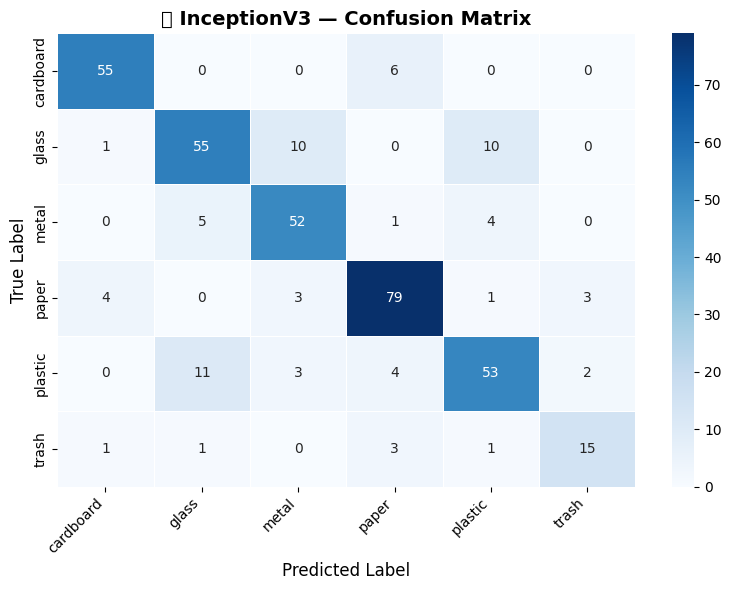

   ✅ Confusion matrix saved: D:\RecycleVision\models\InceptionV3_confusion_matrix.png


In [ ]:
# Cell 8 - Evaluate InceptionV3
m = MODEL_REGISTRY[4]
print('=' * 55)
print(f"{m['icon']} EVALUATING: {m['name']}")
print('=' * 55)

model     = keras.models.load_model(os.path.join(MODELS_PATH, m['file']))
test_gen  = get_test_generator(m['preprocess'])

y_true, y_pred, y_probs = evaluate_model(model, test_gen)
all_y_true[m['name']]   = y_true
all_y_pred[m['name']]   = y_pred
all_y_probs[m['name']]  = y_probs

metrics = get_metrics(y_true, y_pred)
metrics['Model'] = m['name']
all_metrics.append(metrics)

print(f"   Accuracy  : {metrics['Accuracy']}%")
print(f"   Precision : {metrics['Precision']}%")
print(f"   Recall    : {metrics['Recall']}%")
print(f"   F1-Score  : {metrics['F1-Score']}%")
print()
print('📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASSES))

plot_confusion_matrix(y_true, y_pred, m['name'], m['color'])

## 🔲 Cell 9 — Full Metrics Comparison Table

In [ ]:
# Cell 9 - Full Metrics Comparison Table
print('=' * 70)
print('        📊 FULL EVALUATION METRICS — ALL 5 MODELS')
print('=' * 70)

df_metrics = pd.DataFrame(all_metrics)[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]
df_metrics = df_metrics.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print(df_metrics.to_string(index=False))
print('=' * 70)

best_model = df_metrics.iloc[0]
print(f"\n🏆 BEST MODEL : {best_model['Model']}")
print(f"   Accuracy   : {best_model['Accuracy']}%")
print(f"   Precision  : {best_model['Precision']}%")
print(f"   Recall     : {best_model['Recall']}%")
print(f"   F1-Score   : {best_model['F1-Score']}%")
print('=' * 70)

# Save metrics to CSV
csv_path = os.path.join(MODELS_PATH, 'model_evaluation_results.csv')
df_metrics.to_csv(csv_path, index=False)
print(f'\n✅ Metrics saved to: {csv_path}')

        📊 FULL EVALUATION METRICS — ALL 5 MODELS
         Model  Accuracy  Precision  Recall  F1-Score
      ResNet50     90.86      91.05   90.86     90.81
   MobileNetV2     84.33      84.38   84.33     84.25
         VGG16     83.29      83.78   83.29     83.35
   InceptionV3     80.68      80.61   80.68     80.59
EfficientNetB0     78.33      79.55   78.33     78.18

🏆 BEST MODEL : ResNet50
   Accuracy   : 90.86%
   Precision  : 91.05%
   Recall     : 90.86%
   F1-Score   : 90.81%

✅ Metrics saved to: D:\RecycleVision\models\model_evaluation_results.csv


## 🔲 Cell 10 — Metrics Bar Chart (All 4 Metrics)

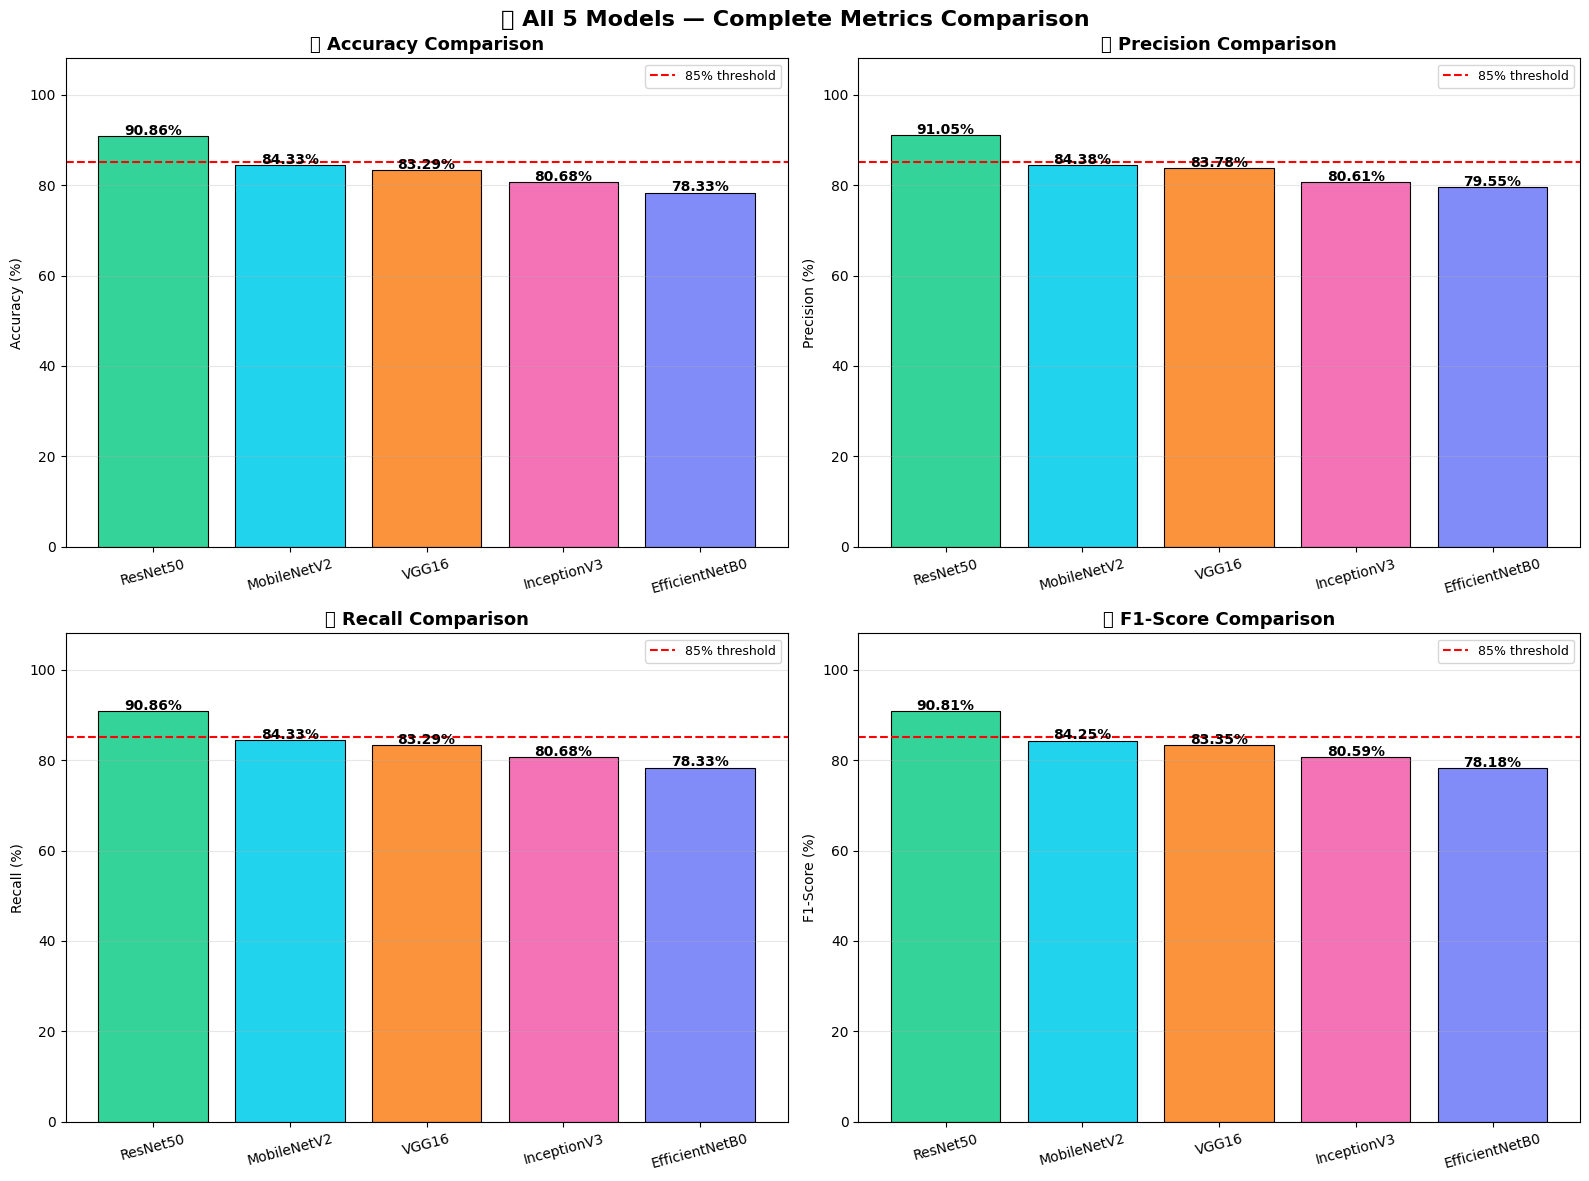

✅ Metrics comparison chart saved: D:\RecycleVision\models\all_metrics_comparison.png


In [ ]:
# Cell 10 - Grouped Bar Chart for All Metrics
model_names   = df_metrics['Model'].tolist()
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_colors  = ['#22d3ee', '#818cf8', '#34d399', '#fb923c', '#f472b6']

# Reorder colors to match sorted df_metrics
color_map = {
    'MobileNetV2'   : '#22d3ee',
    'EfficientNetB0': '#818cf8',
    'ResNet50'      : '#34d399',
    'VGG16'         : '#fb923c',
    'InceptionV3'   : '#f472b6'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(metric_names):
    values = df_metrics[metric].tolist()
    colors = [color_map[m] for m in model_names]
    bars   = axes[idx].bar(model_names, values, color=colors,
                           edgecolor='black', linewidth=0.8)

    for bar, val in zip(bars, values):
        axes[idx].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center',
            fontweight='bold', fontsize=10
        )

    axes[idx].set_title(f'📊 {metric} Comparison', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(f'{metric} (%)')
    axes[idx].set_ylim(0, 108)
    axes[idx].tick_params(axis='x', rotation=15)
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].axhline(y=85, color='red', linestyle='--',
                      linewidth=1.5, label='85% threshold')
    axes[idx].legend(fontsize=9)

plt.suptitle('🏆 All 5 Models — Complete Metrics Comparison',
             fontsize=16, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(MODELS_PATH, 'all_metrics_comparison.png')
plt.savefig(save_path, dpi=150)
plt.show()
print(f'✅ Metrics comparison chart saved: {save_path}')

## 🔲 Cell 11 — ROC Curve (Best Model)

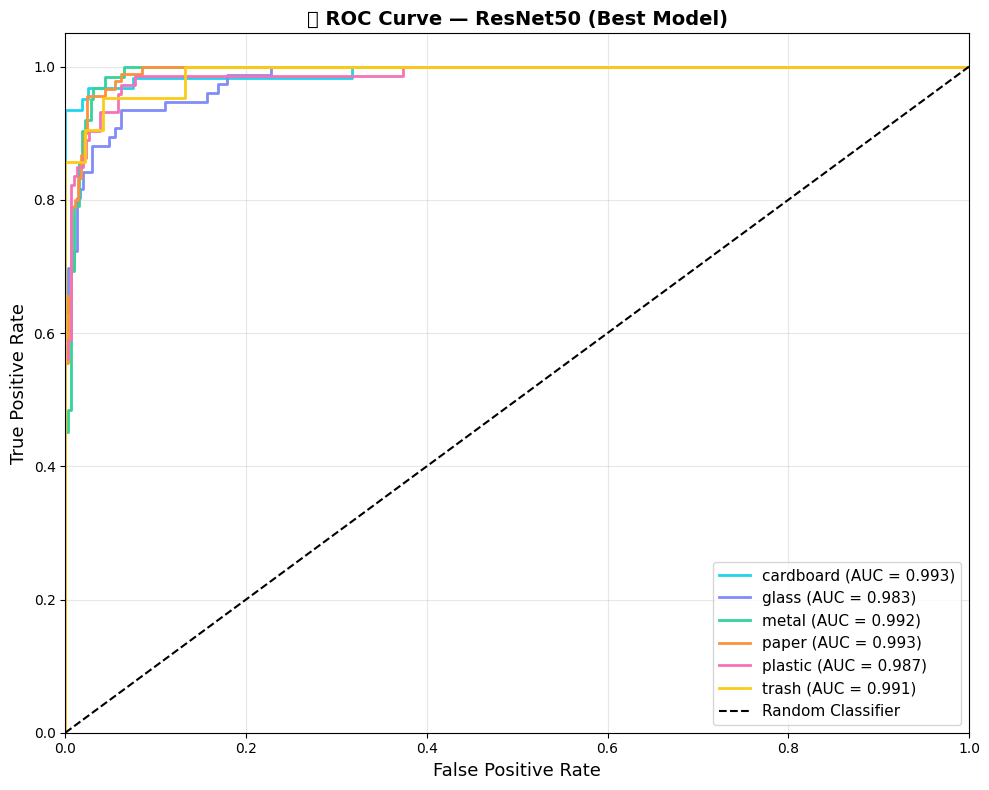

✅ ROC curve saved: D:\RecycleVision\models\ResNet50_ROC_curve.png


In [ ]:
# Cell 11 - ROC Curve for Best Model
best_model_name = df_metrics.iloc[0]['Model']
y_true_best     = all_y_true[best_model_name]
y_probs_best    = all_y_probs[best_model_name]

# Binarize labels for multi-class ROC
y_true_bin = label_binarize(y_true_best, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(10, 8))
roc_colors = ['#22d3ee', '#818cf8', '#34d399', '#fb923c', '#f472b6', '#facc15']

for i, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_best[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=roc_colors[i], linewidth=2,
             label=f'{cls} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate',  fontsize=13)
plt.title(f'📈 ROC Curve — {best_model_name} (Best Model)',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_path = os.path.join(MODELS_PATH, f'{best_model_name}_ROC_curve.png')
plt.savefig(save_path, dpi=150)
plt.show()
print(f'✅ ROC curve saved: {save_path}')

## 🔲 Cell 12 — All Confusion Matrices Side by Side

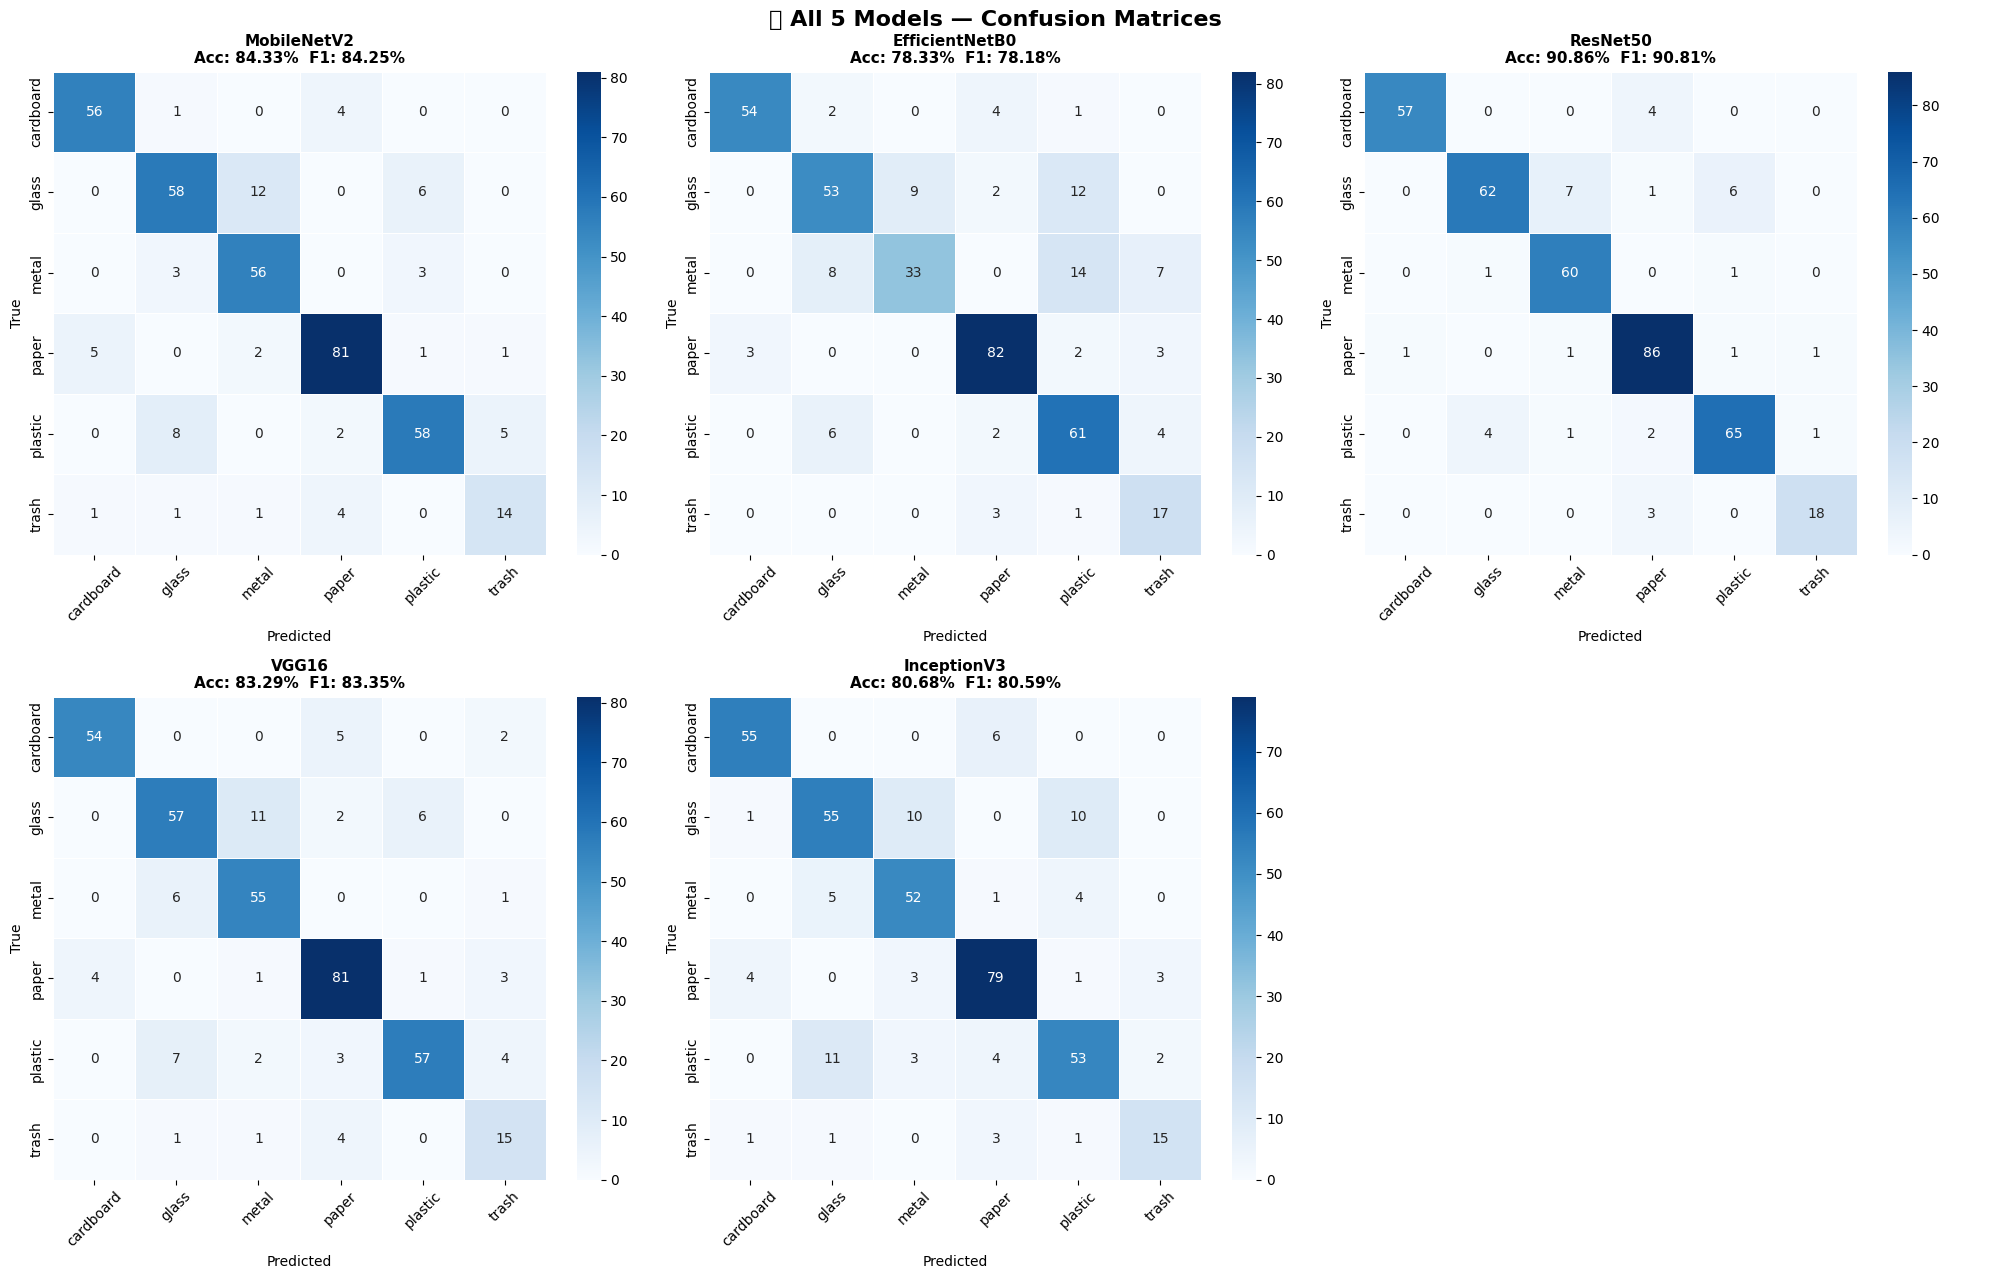

✅ All confusion matrices saved: D:\RecycleVision\models\all_confusion_matrices.png


In [ ]:
# Cell 12 - All 5 Confusion Matrices Side by Side
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes      = axes.flatten()

model_info = [
    ('MobileNetV2',    '#22d3ee'),
    ('EfficientNetB0', '#818cf8'),
    ('ResNet50',       '#34d399'),
    ('VGG16',          '#fb923c'),
    ('InceptionV3',    '#f472b6'),
]

for idx, (name, color) in enumerate(model_info):
    cm = confusion_matrix(all_y_true[name], all_y_pred[name])
    sns.heatmap(
        cm, annot=True, fmt='d',
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        cmap='Blues', ax=axes[idx],
        linewidths=0.5
    )
    f1  = df_metrics[df_metrics['Model'] == name]['F1-Score'].values[0]
    acc = df_metrics[df_metrics['Model'] == name]['Accuracy'].values[0]
    axes[idx].set_title(f'{name}\nAcc: {acc}%  F1: {f1}%',
                        fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('True',      fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)

# Hide 6th subplot (we only have 5 models)
axes[5].axis('off')

plt.suptitle('🔢 All 5 Models — Confusion Matrices',
             fontsize=16, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(MODELS_PATH, 'all_confusion_matrices.png')
plt.savefig(save_path, dpi=150)
plt.show()
print(f'✅ All confusion matrices saved: {save_path}')

## 🔲 Cell 13 — Best Model Selection & Final Summary

In [ ]:
# Cell 13 - Best Model Selection & Final Summary
best = df_metrics.iloc[0]

print('=' * 65)
print('   🏆 BEST MODEL SELECTION — FINAL DECISION')
print('=' * 65)
print(f"   Model      : {best['Model']}")
print(f"   Accuracy   : {best['Accuracy']}%")
print(f"   Precision  : {best['Precision']}%")
print(f"   Recall     : {best['Recall']}%")
print(f"   F1-Score   : {best['F1-Score']}%  ← Selection criteria")
print('=' * 65)
print()
print('📊 ALL MODELS RANKED BY F1-SCORE:')
print('-' * 65)
for rank, (_, row) in enumerate(df_metrics.iterrows(), 1):
    medal = '🥇' if rank == 1 else '🥈' if rank == 2 else '🥉' if rank == 3 else f'  {rank}.'
    print(f"  {medal} {row['Model']:<18} "
          f"Acc: {row['Accuracy']}%  "
          f"F1: {row['F1-Score']}%")
print('-' * 65)
print()
print('=' * 65)
print('   ✅ MODEL EVALUATION COMPLETE!')
print('=' * 65)
print(f"  Best model file : {best['Model'].lower().replace('efficientnetb0','efficientnetb0').replace(' ','')}_model.h5")
print(f"  Use this model  : in Streamlit app for predictions")
print()
print('🔜 Next Step: Streamlit App Development')
print('   → Upload garbage image')
print('   → Predict waste category')
print('   → Show confidence score & Top-3 predictions')
print('=' * 65)

   🏆 BEST MODEL SELECTION — FINAL DECISION
   Model      : ResNet50
   Accuracy   : 90.86%
   Precision  : 91.05%
   Recall     : 90.86%
   F1-Score   : 90.81%  ← Selection criteria

📊 ALL MODELS RANKED BY F1-SCORE:
-----------------------------------------------------------------
  🥇 ResNet50           Acc: 90.86%  F1: 90.81%
  🥈 MobileNetV2        Acc: 84.33%  F1: 84.25%
  🥉 VGG16              Acc: 83.29%  F1: 83.35%
    4. InceptionV3        Acc: 80.68%  F1: 80.59%
    5. EfficientNetB0     Acc: 78.33%  F1: 78.18%
-----------------------------------------------------------------

   ✅ MODEL EVALUATION COMPLETE!
  Best model file : resnet50_model.h5
  Use this model  : in Streamlit app for predictions

🔜 Next Step: Streamlit App Development
   → Upload garbage image
   → Predict waste category
   → Show confidence score & Top-3 predictions
